# <font color=darkred>Laboratory 17: Sampling and Simulations</font>

## Full name: Graysen Gould
## R#: 11944656
## Title of the notebook: Laboratory 17: Sampling and Simulations
## Date: 11/11/2024 
___

In [1]:
# Preamble script block to identify host, user, and kernel
import sys
! hostname
! whoami
print(sys.executable)
print(sys.version)
print(sys.version_info)

GouldPC
gouldpc\gould
C:\Users\gould\anaconda3\python.exe
3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
sys.version_info(major=3, minor=12, micro=4, releaselevel='final', serial=0)


# Simulations
Simulations are used in everything from medical research to fashion and rocket launches. However, we're going to start with a few very basic simulations — but the fundamental principles remain the same! To write a simulation, we need to identify all the factors that might influence the outcome and write Python code to simulate each of these factors.

##  Simple Simulations in Python
The goal of the code we will develop is to store the results of every run of our simulation in a DataFrame. By storing the data in a DataFrame, we can use all the tools and techniques we already know to:

- Select a subset of rows.
- Group data.
- Find descriptive statistics.
- And more!

Almost all simulations will follow a similar "pattern," with only a few select areas needing modification to solve a variety of different problems.

### Simulation Pattern

Every simulation we write will follow a six-step pattern:

1. **Create an Empty List**
   - We will start by creating an initially empty Python list called `data` to accumulate each run of our simulation. This will always be:
     ```python
     data = []
     ```

2. **Write a For-Loop**
   - We will write a for-loop to execute a block of code for each run of our simulation. For a 10,000-run simulation, the loop will look like this:
     ```python
     for i in range(10000):
     ```

3. **Simulate Real-World Factors**
   - Inside the for-loop, we will simulate all real-world factors. For example, in a simple simulation of a six-sided die roll, the code will be:
     ```python
     roll = random.randint(1, 6)
     ```

4. **Accumulate Results in a Dictionary**
   - Inside the for-loop, we will store the simulated factors in a Python dictionary called `d`. A dictionary consists of key-value pairs enclosed in curly braces `{}` and separated by commas. The key in the dictionary will match the name of the real-world factor, enclosed in quotes.
   
   - For example:
     - For a single real-world variable `roll`:
       ```python
       d = { "roll": roll }
       ```
     - For two real-world variables `red` and `blue`:
       ```python
       d = { "red": red, "blue": blue }
       ```
     - For a real-world variable `height`:
       ```python
       d = { "height": height }
       ```
     - For two real-world variables `one` and `two`:
       ```python
       d = { "one": one, "two": two }
       ```

   - We always refer to the variable by its name, which helps in creating columns in our DataFrame with these variable names.

5. **Append the Dictionary to the List**
   - Inside the for-loop, we will append each dictionary `d` to our `data` list. This will always be:
     ```python
     data.append(d)
     ```

6. **Save the Data as a DataFrame**
   - Finally, outside the for-loop, we will convert our `data` list into a DataFrame using `pandas`. This will always be:
     ```python
     df = pd.DataFrame(data)
     ```

   - This step creates a DataFrame from the list of dictionaries, allowing us to analyze and manipulate the simulation results.
### Simulation Example

> #### In 2010, the American Civil Liberties Union (ACLU) of Northern California presented a report on jury selection model in Alameda County, California. The report concluded that certain ethnic groups are underrepresented among jury panelists in Alameda County, and suggested some reforms of the process by which eligible jurors are assigned to panels. 

| Ethnicity | Eligible | Panel |
|-----------|----------|-------|
| Asian     | 0.15     | 0.26  |
| Black     | 0.18     | 0.08  |
| Latino    | 0.12     | 0.08  |
| White     | 0.54     | 0.54  |
| Other     | 0.01     | 0.04  |

### We will perform a simulation of the data given below and examine whether there was truly an underrepresentation of certain groups.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Model data for jury selection
raw_data = {
    'Ethnicity': ['Asian', 'Black', 'Latino', 'White', 'Other'],
    'Eligible' : [0.15, 0.18, 0.12, 0.54, 0.01],
    'Panel': [0.26, 0.08, 0.08, 0.54, 0.04]
}
df = pd.DataFrame(raw_data)
df

,Ethnicity,Eligible,Panel
0,Asian,0.15,0.26
1,Black,0.18,0.08
2,Latino,0.12,0.08
3,White,0.54,0.54
4,Other,0.01,0.04


<Axes: ylabel='Ethnicity'>

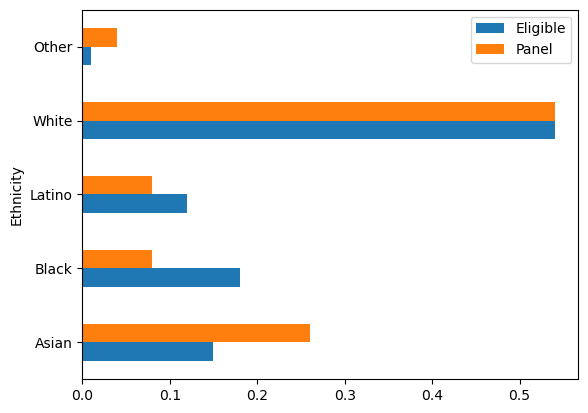

In [4]:
#Plotting horizontal bar chart for 'Eligible' and 'Panel' columns 
df.plot.barh(x='Ethnicity', y=['Eligible', 'Panel'])

In [8]:
#Appending a new column 'EP Difference' with the absolute difference between eligible and panel proportions
df['EP Difference'] = (df['Eligible'] - df['Panel']).abs()
df

,Ethnicity,Eligible,Panel,EP Difference
0,Asian,0.15,0.26,0.11
1,Black,0.18,0.08,0.10
2,Latino,0.12,0.08,0.04
3,White,0.54,0.54,0.00
4,Other,0.01,0.04,0.03


In [9]:
#Computing the observed statistic which is the total variation distance between eligible and panel proportions
observed_total_variance = df['EP Difference'].sum()/2
observed_total_variance

0.14

In [10]:
#Randomly picking one sample of size 1453
#Calculating the total variation distance between random proportions and eligible proportions
groups = df['Ethnicity']
total = 1453
prop = df['Eligible']
random_outcomes = np.random.choice(groups, total, p=prop)
asian_count = np.count_nonzero(random_outcomes=='Asian')
black_count = np.count_nonzero(random_outcomes=='Black')
latino_count = np.count_nonzero(random_outcomes=='Latino')
white_count = np.count_nonzero(random_outcomes=='White')
other_count = np.count_nonzero(random_outcomes=='Other')
sample_prop = np.array([asian_count, black_count, latino_count, white_count, other_count])/total
sample_prop

array([0.15966965, 0.17412251, 0.12181693, 0.53131452, 0.01307639])

In [11]:
#Appending a new column 'Random Sample Panel' with the random sample proportions
df['Random Sample Panel'] = sample_prop
df

,Ethnicity,Eligible,Panel,EP Difference,Random Sample Panel
0,Asian,0.15,0.26,0.11,0.159670
1,Black,0.18,0.08,0.10,0.174123
2,Latino,0.12,0.08,0.04,0.121817
3,White,0.54,0.54,0.00,0.531315
4,Other,0.01,0.04,0.03,0.013076


In [14]:
df["ER Difference"] = (df["Eligible"] - df["Random Sample Panel"])
df

,Ethnicity,Eligible,Panel,EP Difference,Random Sample Panel,ER Difference
0,Asian,0.15,0.26,0.11,0.159670,-0.009670
1,Black,0.18,0.08,0.10,0.174123,0.005877
2,Latino,0.12,0.08,0.04,0.121817,-0.001817
3,White,0.54,0.54,0.00,0.531315,0.008685
4,Other,0.01,0.04,0.03,0.013076,-0.003076


In [15]:
#Computing the test statistic which is the total variation distance between eligible and random proportions for one sample
sample_total_variance = df['ER Difference'].sum() / 2
sample_total_variance

-1.1275702593849246e-17

In [18]:
#Performing simulation by picking 10,000 random samples of size 1453
#Calculating the total variation distance for each of the 10,000 samples
repetitions = 10000
outcomes = []
for i in np.arange(repetitions):
    random_outcomes = np.random.choice(groups, total, p=prop)
    asian_count = np.count_nonzero(random_outcomes=='Asian')
    black_count = np.count_nonzero(random_outcomes=='Black')
    latino_count = np.count_nonzero(random_outcomes=='Latino')
    white_count = np.count_nonzero(random_outcomes=='White')
    other_count = np.count_nonzero(random_outcomes=='Other')

    sample_prop = np.array([asian_count, black_count, latino_count, white_count, other_count])/total
    
    df['Random Sample Panel'] = sample_prop
    sample_dist = ((df['Eligible'] - df['Random Sample Panel']).abs().sum())/2
    outcomes.append(sample_dist)
    
outcomes = np.array(outcomes)

Text(0.5, 1.0, 'Sampling distribution of total variation distance for 10,000 samples of size 1453')

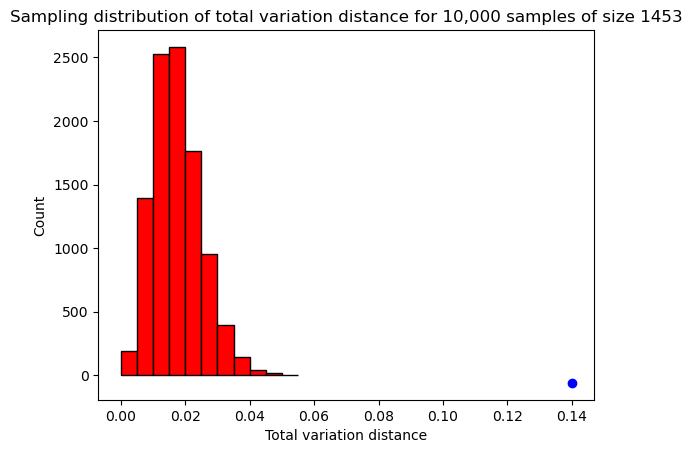

In [19]:
#Plotting a distribution of the test statistic which is the total variation distance along with the observed statistic

plt.hist(outcomes, color='red', ec = 'black', bins=np.arange(0, 0.06, 0.005))
plt.scatter(observed_total_variance, -60, color='blue')
plt.xlabel('Total variation distance')
plt.ylabel('Count')
plt.title('Sampling distribution of total variation distance for 10,000 samples of size 1453')

### Deterministic/Convenience Sampling

One sampling methodology, which is **generally a bad idea**, is to use convenience sampling. For example, you might choose students from your own department or faculty because it is easier to survey them. This approach is known as *convenience sampling* and is considered less rigorous.
#### Code Example
Here’s a simple Python example to illustrate convenience sampling:
```python
import pandas as pd

# Sample data: A DataFrame of students from different faculties
data = {
    'Student': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'Faculty': ['Science', 'Arts', 'Science', 'Arts', 'Science']
}
df = pd.DataFrame(data)
# Convenience sampling: Selecting only students from the 'Science' faculty
convenience_sample = df[df['Faculty'] == 'Science']

___
### Exercise 17.0 (50 marks)

**Question 1.** Using Pandas DataFrame to read the `player_data.csv` file, store the data into a variable called `full_data` and populate last few rows to the screen

In [23]:
import numpy as np
import pandas as pd
full_data = pd.read_csv("player_data.csv")

full_data.tail()

,Name,Age,Team,Salary
487,Adreian Payne,23,TOT,29843
488,Ricky Ledo,22,TOT,29843
489,Gary Harris,20,DEN,29843
490,Zach LaVine,19,MIN,29843
491,Lance Stephenson,24,CHO,14409



**Question 2**  Assign `convenience_sample_data` to a subset of `full_data` that contains only the rows for players under the age of 22. Reset the index and populate the last few rows to the screen.

In [26]:
convenience_sample_data = full_data[full_data["Age"] < 22]
convenience_sample_data.reset_index(inplace = True)
convenience_sample_data.head()

,index,Name,Age,Team,Salary
0,3,Anthony Davis,21,NOP,22458401
1,29,Andre Drummond,21,DET,14746000
2,52,Giannis Antetokounmpo,20,MIL,11440124
3,100,Steven Adams,21,OKC,6792500
4,112,Nerlens Noel,20,PHI,6253521


**Question 3.** Compute and assign `convenience_age` and `convenience_salary` to the average age and average salary of your convenience sample.  Since they're computed on a sample, these are called *sample averages*.

In [29]:
convenience_age = convenience_sample_data["Age"].mean()
convenience_salary = convenience_sample_data["Salary"].mean()
print(f"Average Age of Convenience Sample: {round(convenience_age,2)}, \nAverage salary: {convenience_salary}")

Average Age of Convenience Sample: 20.36, 
Average salary: 2878411.0


**Question 4.** Compute and assign `avg_age` and `avg_salary` to the average age and average salary of your `full_data`. 

In [31]:
avg_age = full_data["Age"].mean()
avg_salary = full_data["Salary"].mean()
print(f"Average Age of full sample: {round(avg_age,2)}, \nAverage salary: {round(avg_salary,2)}")

Average Age of full sample: 26.54, 
Average salary: 4269775.77


**Question 5.** Does the convenience sample give us an accurate picture of the age and salary of the full population of NBA players in 2014-2015?  Would you expect it to, in general?  Before you move on, write a short answer in English below.  You can refer to the statistics calculated above or perform your own analysis.

In [39]:
# no, the average age and the average salary between the convenience sample and the full sample are vastly different
# this is because we chose young players for the convenience sample, whose salaries are on average much lower

#calculating the percent difference
age_diff = abs((avg_age - convenience_age)/avg_age *100)
salary_diff = abs((avg_salary - convenience_salary)/avg_salary *100)

print(f"the average age in the convenience sample is {round(age_diff, 2)}% lower, and the average salary is {round(salary_diff, 2)}% lower")

the average age in the convenience sample is 23.26% lower, and the average salary is 32.59% lower


___
### Simple random sampling
Simple random sampling is a fundamental technique in statistics where every member of a population has an equal chance of being selected. This method helps to ensure that the sample is representative of the population.
#### Code Example
Here’s a Python example of simple random sampling using the `random` library:
```python
import pandas as pd
import random
# Sample data: A DataFrame of students from different faculties
data = {
    'Student': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'Faculty': ['Science', 'Arts', 'Science', 'Arts', 'Science']
}
df = pd.DataFrame(data)
# Simple random sampling: Select 2 students randomly from the DataFrame
sample_size = 2
random_sample = df.sample(n=sample_size, random_state=1)
print(random_sample)


### Exercise 17.1  (50 Marks)
**Question 6.** Produce a simple random sample of size 44 from `full_data`. Compute the sample averages (salary and age) again.  Are your results similar to `full_data` age and salary averages?  Run your code several times to get new samples.  How much do things change across samples?

average sample age difference: 0.013085
average sample salary difference: -14150.324922


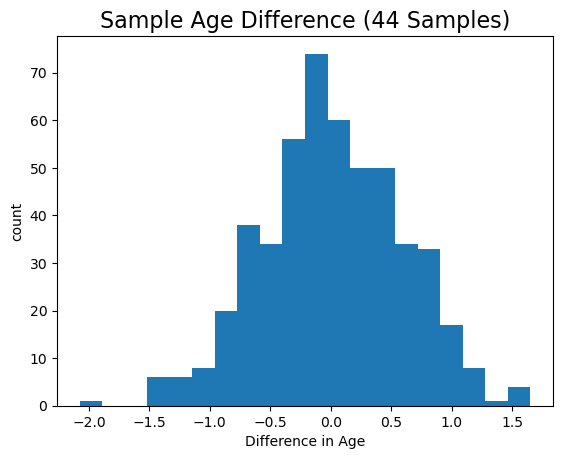

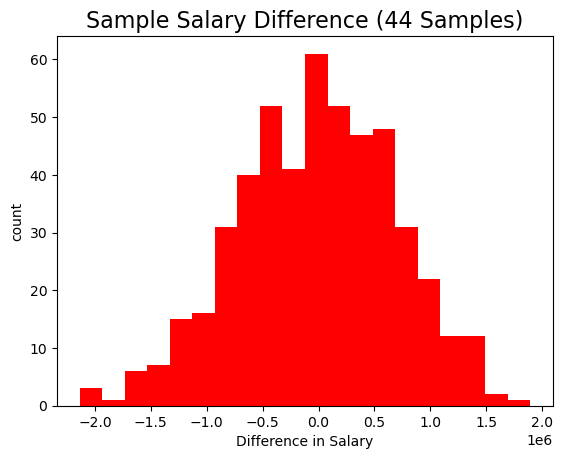

In [93]:
import matplotlib.pyplot as plt
sample_size = 44
age_results = []
salary_results = []
num_samples = 500

for i in range(num_samples):
    sample_data = full_data.sample(n = sample_size)
    sample_age = sample_data["Age"].mean()
    sample_salary = sample_data["Salary"].mean()
    age_diff = avg_age - sample_age
    salary_diff = avg_salary - sample_salary
    age_results.append(age_diff)
    salary_results.append(salary_diff)

print(f"average sample age difference: {round(sum(age_results)/len(age_results), 6)}")
print(f"average sample salary difference: {round(sum(salary_results)/len(salary_results), 6)}")
    
plt.hist(age_results, bins = 20)

plt.title("Sample Age Difference (44 Samples)", fontsize = 16)
plt.xlabel("Difference in Age")
plt.ylabel("count")
plt.show()

plt.figure()

plt.hist(salary_results, bins = 20, color = "red")
plt.title("Sample Salary Difference (44 Samples)", fontsize = 16)
plt.xlabel("Difference in Salary")
plt.ylabel("count")
plt.show()


**Question 7** As in the previous question, analyze several simple random samples of size 100 from `full_data`.  Do the average and histogram statistics seem to change more or less across samples of this size than across samples of size 44?  And are the sample averages and histograms closer to their true values (`full_data` averages) for age or for salary?  What did you expect to see?

average sample age difference: 0.025225
average sample salary difference: -1798.77294


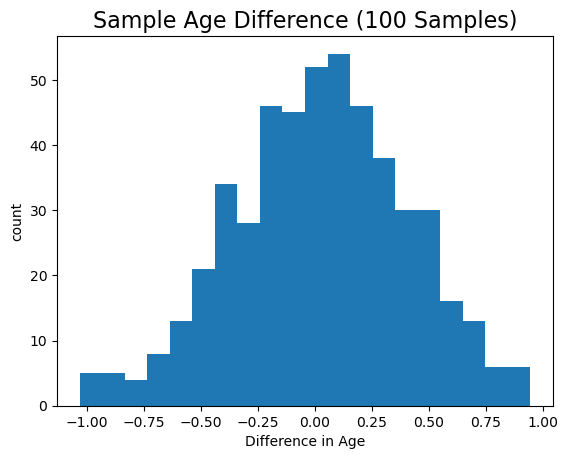

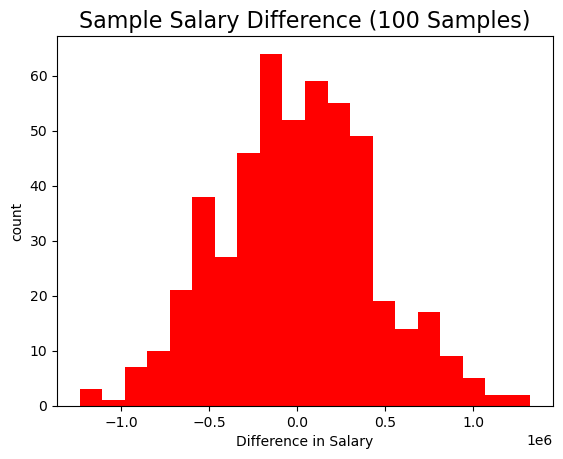

In [94]:
# now with sample size = 100
sample_size = 100
age_results = []
salary_results = []
num_samples = 500

for i in range(num_samples):
    sample_data = full_data.sample(n = sample_size)
    sample_age = sample_data["Age"].mean()
    sample_salary = sample_data["Salary"].mean()
    age_diff = avg_age - sample_age
    salary_diff = avg_salary - sample_salary
    age_results.append(age_diff)
    salary_results.append(salary_diff)

print(f"average sample age difference: {round(sum(age_results)/len(age_results), 6)}")
print(f"average sample salary difference: {round(sum(salary_results)/len(salary_results), 6)}")

plt.hist(age_results, bins = 20)

plt.title("Sample Age Difference (100 Samples)", fontsize = 16)
plt.xlabel("Difference in Age")
plt.ylabel("count")
plt.show()

plt.figure()

plt.hist(salary_results, bins = 20, color = "red")
plt.title("Sample Salary Difference (100 Samples)", fontsize = 16)
plt.xlabel("Difference in Salary")
plt.ylabel("count")
plt.show()


In [70]:
# yes, the sample with a size of 100 seems to be a bit more accurate in estimating the average age and average salary

**Question 8.** Repeat process in **Question 6** and **Question 7** using sample with replacement technique, then analyze any difference from prior results

average sample age difference: -0.02296
average sample salary difference: -13566.830103


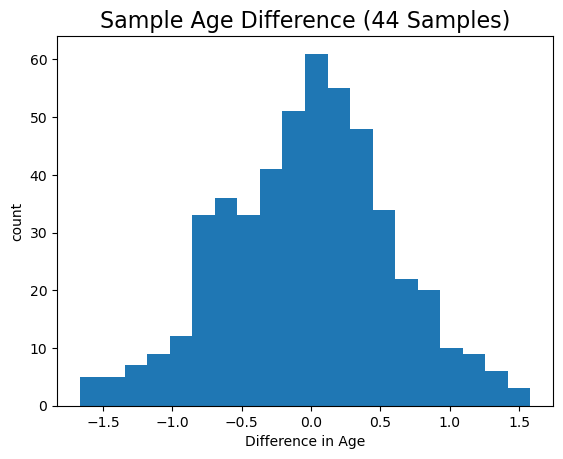

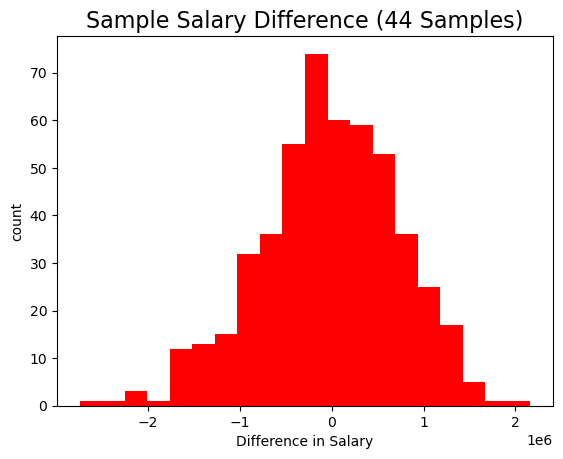

In [95]:
#sample size of 44 with replacement

import matplotlib.pyplot as plt
sample_size = 44
age_results = []
salary_results = []
num_samples = 500

for i in range(num_samples):
    sample_data = full_data.sample(n = sample_size, replace = True)
    sample_age = sample_data["Age"].mean()
    sample_salary = sample_data["Salary"].mean()
    age_diff = avg_age - sample_age
    salary_diff = avg_salary - sample_salary
    age_results.append(age_diff)
    salary_results.append(salary_diff)

print(f"average sample age difference: {round(sum(age_results)/len(age_results), 6)}")
print(f"average sample salary difference: {round(sum(salary_results)/len(salary_results), 6)}")
    
plt.hist(age_results, bins = 20)

plt.title("Sample Age Difference (44 Samples)", fontsize = 16)
plt.xlabel("Difference in Age")
plt.ylabel("count")
plt.show()

plt.figure()

plt.hist(salary_results, bins = 20, color = "red")
plt.title("Sample Salary Difference (44 Samples)", fontsize = 16)
plt.xlabel("Difference in Salary")
plt.ylabel("count")
plt.show()

average sample age difference: 0.003885
average sample salary difference: -623.50406


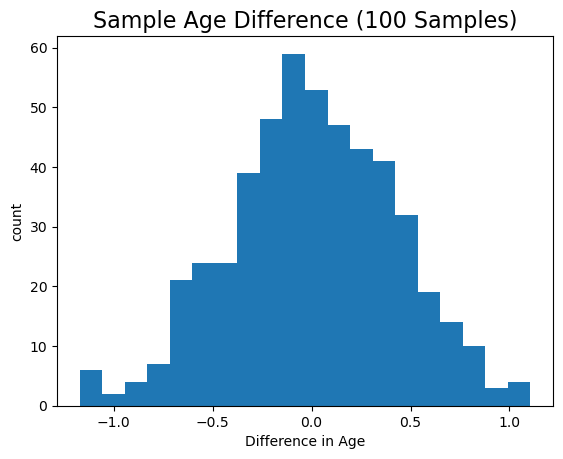

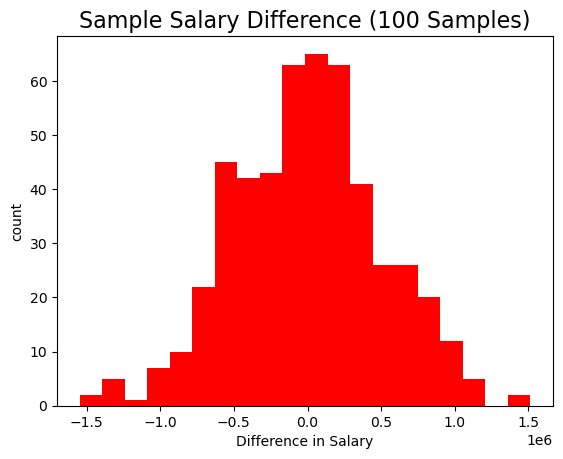

In [96]:
# sample size of 100 with replacement
sample_size = 100
age_results = []
salary_results = []
num_samples = 500

for i in range(num_samples):
    sample_data = full_data.sample(n = sample_size, replace = True)
    sample_age = sample_data["Age"].mean()
    sample_salary = sample_data["Salary"].mean()
    age_diff = avg_age - sample_age
    salary_diff = avg_salary - sample_salary
    age_results.append(age_diff)
    salary_results.append(salary_diff)

print(f"average sample age difference: {round(sum(age_results)/len(age_results), 6)}")
print(f"average sample salary difference: {round(sum(salary_results)/len(salary_results), 6)}")

plt.hist(age_results, bins = 20)

plt.title("Sample Age Difference (100 Samples)", fontsize = 16)
plt.xlabel("Difference in Age")
plt.ylabel("count")
plt.show()

plt.figure()

plt.hist(salary_results, bins = 20, color = "red")
plt.title("Sample Salary Difference (100 Samples)", fontsize = 16)
plt.xlabel("Difference in Salary")
plt.ylabel("count")
plt.show()

In [ ]:
# the results of the samples with relacement seem to be very similar to the samples without replacement.
# the main difference is that the histograms with replacement have histograms more tighly concentrated at the center

**Question 9.** Simulate and plot **without replacement** the Average Salary and Age of 100 samples 

average sample age difference: 0.031025
average sample salary difference: 13954.18184


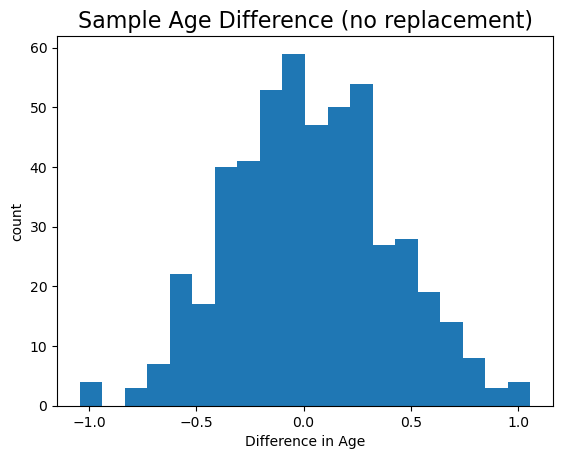

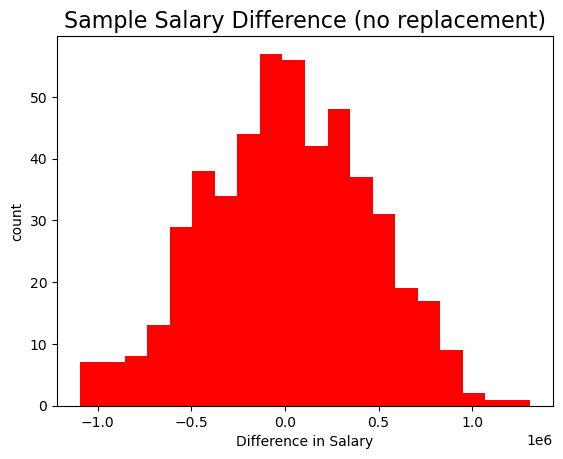

In [98]:
# repeating what I did above
sample_size = 100
age_results = []
salary_results = []
num_samples = 500

for i in range(num_samples):
    sample_data = full_data.sample(n = sample_size)
    sample_age = sample_data["Age"].mean()
    sample_salary = sample_data["Salary"].mean()
    age_diff = avg_age - sample_age
    salary_diff = avg_salary - sample_salary
    age_results.append(age_diff)
    salary_results.append(salary_diff)

print(f"average sample age difference: {round(sum(age_results)/len(age_results), 6)}")
print(f"average sample salary difference: {round(sum(salary_results)/len(salary_results), 6)}")

plt.hist(age_results, bins = 20)

plt.title("Sample Age Difference (no replacement)", fontsize = 16)
plt.xlabel("Difference in Age")
plt.ylabel("count")
plt.show()

plt.figure()

plt.hist(salary_results, bins = 20, color = "red")
plt.title("Sample Salary Difference (no replacement)", fontsize = 16)
plt.xlabel("Difference in Salary")
plt.ylabel("count")
plt.show()



**Question 10.** Simulate and plot **replacement** the Average Salary and Age of 100 samples 

average sample age difference: -0.041615
average sample salary difference: 3789.16312


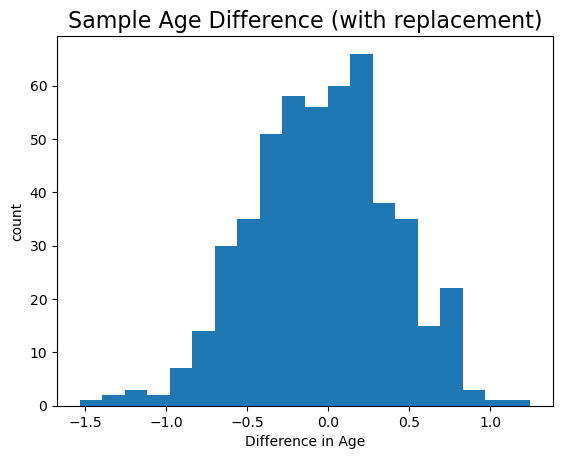

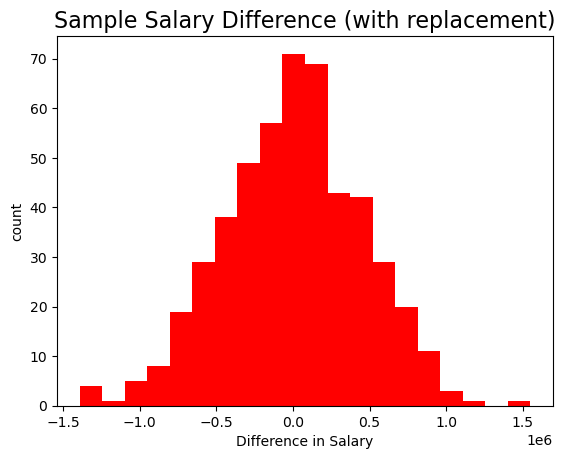

In [99]:
# sample size of 100 with replacement
sample_size = 100
age_results = []
salary_results = []
num_samples = 500

for i in range(num_samples):
    sample_data = full_data.sample(n = sample_size, replace = True)
    sample_age = sample_data["Age"].mean()
    sample_salary = sample_data["Salary"].mean()
    age_diff = avg_age - sample_age
    salary_diff = avg_salary - sample_salary
    age_results.append(age_diff)
    salary_results.append(salary_diff)

print(f"average sample age difference: {round(sum(age_results)/len(age_results), 6)}")
print(f"average sample salary difference: {round(sum(salary_results)/len(salary_results), 6)}")

plt.hist(age_results, bins = 20)

plt.title("Sample Age Difference (with replacement)", fontsize = 16)
plt.xlabel("Difference in Age")
plt.ylabel("count")
plt.show()

plt.figure()

plt.hist(salary_results, bins = 20, color = "red")
plt.title("Sample Salary Difference (with replacement)", fontsize = 16)
plt.xlabel("Difference in Salary")
plt.ylabel("count")
plt.show()